# Notebook 01 - DBI Framework Refinement

Tinh chỉnh Digital Burnout Indicator (DBI) Framework dựa trên bằng chứng thực nghiệm thu được từ hai bộ dữ liệu International Dataset và Vietnam Dataset sau khi hoàn thành quá trình Feature Validation và Machine Learning.

- Xác định các indicator xuất hiện ở cả hai bộ dữ liệu.
- Đánh giá mức độ nhất quán của indicator thông qua Feature Validation và SHAP Analysis.
- Phân loại mức độ ưu tiên của từng indicator.
- Hoàn thiện Final DBI Framework phục vụ các bước phân tích và ứng dụng tiếp theo.

# 0. Set Up

Thiết lập môi trường phân tích và chuẩn hóa các đường dẫn dữ liệu phục vụ quá trình xây dựng DBI Framework.

In [10]:
# Import các thư viện cần thiết

import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập đường dẫn thư mục dự án

project_path = Path("../../").resolve()

# Khai báo đường dẫn dữ liệu đầu vào

international_validation_path = (
    project_path
    / "data"
    / "processed"
    / "international_dataset"
    / "validated_features.csv"
)

vietnam_validation_path = (
    project_path
    / "data"
    / "processed"
    / "vietnam_dataset"
    / "validated_features.csv"
)

international_shap_path = (
    project_path
    / "results"
    / "international_dataset"
    / "shap_feature_importance.csv"
)

vietnam_shap_path = (
    project_path
    / "results"
    / "vietnam_dataset"
    / "shap_feature_importance.csv"
)

# Khai báo thư mục lưu kết quả

output_path = (
    project_path
    / "results"
    / "cross_dataset"
)

output_path.mkdir(
    parents=True,
    exist_ok=True
)

print("Đã thiết lập môi trường làm việc.")
print(f"Thư mục dự án: {project_path}")

Đã thiết lập môi trường làm việc.
Thư mục dự án: D:\DA016


# 1. Load Validation and SHAP Results

Đọc kết quả Feature Validation và SHAP của hai bộ dữ liệu nghiên cứu, sau đó chuẩn hóa cấu trúc dữ liệu nhằm tạo đầu vào thống nhất cho quá trình phân tích và so sánh ở các bước tiếp theo.

Kết quả từ International Dataset và Vietnam Dataset được tạo ra từ các notebook độc lập nên có sự khác biệt về tên cột và định dạng dữ liệu. Trong phần này, các kết quả sẽ được chuẩn hóa về cùng một cấu trúc, bao gồm:

- Kết quả Feature Validation của International Dataset.
- Kết quả Feature Validation của Vietnam Dataset.
- Kết quả SHAP của International Dataset.
- Kết quả SHAP của Vietnam Dataset.

Sau khi chuẩn hóa, toàn bộ indicator sẽ được biểu diễn theo cùng một định danh để phục vụ cho quá trình xây dựng Final DBI Framework.

## 1.1 Load Validation and SHAP Results

Đọc kết quả Feature Validation và SHAP Analysis của International Dataset và Vietnam Dataset nhằm chuẩn bị dữ liệu phục vụ cho quá trình so sánh và tinh chỉnh Digital Burnout Indicator (DBI) Framework.

Phần này thực hiện:

- Đọc kết quả Feature Validation của hai bộ dữ liệu.
- Đọc kết quả SHAP Feature Importance của hai bộ dữ liệu.
- Kiểm tra cấu trúc dữ liệu sau khi tải.

Lưu ý rằng:

- International Dataset sử dụng tên cột `feature`.
- Vietnam Dataset sử dụng tên cột `Feature`.

Sự khác biệt này sẽ được chuẩn hóa ở các phần tiếp theo.

In [11]:
# Đọc kết quả Feature Validation và SHAP Analysis

international_validation = pd.read_csv(
    international_validation_path
)

vietnam_validation = pd.read_csv(
    vietnam_validation_path
)

international_shap = pd.read_csv(
    international_shap_path
)

vietnam_shap = pd.read_csv(
    vietnam_shap_path
)

print("Đã tải kết quả Feature Validation và SHAP Analysis.")
print(f"Số lượng feature của International Validation: {international_validation.shape[0]}")
print(f"Số lượng feature của Vietnam Validation: {vietnam_validation.shape[0]}")
print(f"Số lượng feature của International SHAP: {international_shap.shape[0]}")
print(f"Số lượng feature của Vietnam SHAP: {vietnam_shap.shape[0]}")

Đã tải kết quả Feature Validation và SHAP Analysis.
Số lượng feature của International Validation: 26
Số lượng feature của Vietnam Validation: 21
Số lượng feature của International SHAP: 26
Số lượng feature của Vietnam SHAP: 15


In [12]:
# Kiểm tra cấu trúc các bộ dữ liệu

print("Các cột của International Validation:")
print(international_validation.columns.tolist())

print()

print("Các cột của Vietnam Validation:")
print(vietnam_validation.columns.tolist())

print()

print("Các cột của International SHAP:")
print(international_shap.columns.tolist())

print()

print("Các cột của Vietnam SHAP:")
print(vietnam_shap.columns.tolist())

Các cột của International Validation:
['feature', 'f_score', 'p_value', 'significant', 'importance', 'rf_rank', 'anova_rank', 'rank_difference', 'feature_status']

Các cột của Vietnam Validation:
['Feature', 'F-Statistic', 'P-Value', 'Importance', 'ANOVA_Rank', 'RF_Rank', 'Average_Rank', 'feature_status']

Các cột của International SHAP:
['feature', 'mean_shap', 'mean_abs_shap']

Các cột của Vietnam SHAP:
['Feature', 'Mean_SHAP']


In [13]:
# Hiển thị một số dòng dữ liệu

display(international_validation.head())

display(vietnam_validation.head())

display(international_shap.head())

display(vietnam_shap.head())

,feature,f_score,p_value,significant,importance,rf_rank,anova_rank,rank_difference,feature_status
0,emotional_exhaustion,693837.690271,0.0,True,0.227302,1,1,0,Core Feature
1,stress_level,339866.544911,0.0,True,0.135371,2,2,0,Core Feature
2,daily_screen_time,101564.936783,0.0,True,0.067815,3,4,1,Core Feature
3,work_satisfaction,137327.575101,0.0,True,0.065593,4,3,1,Core Feature
4,doomscrolling_duration,83030.435719,0.0,True,0.054545,5,5,0,Core Feature


,Feature,F-Statistic,P-Value,Importance,ANOVA_Rank,RF_Rank,Average_Rank,feature_status
0,digital_exhaustion,77.528278,6.289798e-31,0.099671,1.0,2.0,1.5,Core Feature
1,digital_stress,74.983400,4.944099e-30,0.085296,2.0,3.0,2.5,Core Feature
2,performance_decline,70.502365,1.926286e-28,0.079153,3.0,5.0,4.0,Core Feature
3,physical_fatigue,61.058877,4.973406e-25,0.082970,4.0,4.0,4.0,Core Feature
4,loss_of_interest,31.369879,9.848678e-14,0.108078,7.0,1.0,4.0,Core Feature


,feature,mean_shap,mean_abs_shap
0,emotional_exhaustion,-0.255703,0.761339
1,stress_level,-0.146301,0.565297
2,work_satisfaction,-0.059630,0.365784
3,daily_screen_time,-0.045927,0.293019
4,doomscrolling_duration,-0.036148,0.271082


,Feature,Mean_SHAP
0,numerical__app_switch_frequency,0.399335
1,numerical__smartphone_unlocks,0.347211
2,numerical__motivation_level,0.333562
3,numerical__doomscrolling_duration,0.297905
4,numerical__sleep_hours,0.278166


## 1.2 Standardize Indicator Results

Chuẩn hóa tên indicator và cấu trúc dữ liệu giữa hai bộ dữ liệu nhằm tạo định dạng thống nhất cho các bước so sánh trong notebook.

Kết quả Feature Validation và SHAP của International Dataset và Vietnam Dataset được chuẩn hóa về cùng tên cột. Đồng thời loại bỏ tiền tố `numerical__` trong kết quả SHAP của Vietnam Dataset để đảm bảo các indicator có cùng định danh.

In [19]:
# Chuẩn hóa kết quả Feature Validation

international_validation_std = (
    international_validation[
        ["feature", "feature_status"]
    ]
    .rename(columns={"feature": "indicator"})
)

vietnam_validation_std = (
    vietnam_validation[
        ["Feature", "feature_status"]
    ]
    .rename(columns={"Feature": "indicator"})
)

# Chuẩn hóa kết quả SHAP

international_shap_std = (
    international_shap[
        ["feature", "mean_abs_shap"]
    ]
    .rename(columns={"feature": "indicator"})
)

vietnam_shap_std = (
    vietnam_shap[
        ["Feature", "Mean_SHAP"]
    ]
    .rename(
        columns={
            "Feature": "indicator",
            "Mean_SHAP": "mean_abs_shap"
        }
    )
)

# Chuẩn hóa tên indicator

for dataframe in [
    international_validation_std,
    vietnam_validation_std,
    international_shap_std,
    vietnam_shap_std
]:
    dataframe["indicator"] = (
        dataframe["indicator"]
        .str.replace("numerical__", "", regex=False)
        .str.strip()
        .str.lower()
    )

print("Đã chuẩn hóa dữ liệu thành công.")

Đã chuẩn hóa dữ liệu thành công.


# 2. Indicator Coverage Comparison

Xác định mức độ bao phủ của các Digital Burnout Indicator giữa International Dataset và Vietnam Dataset thông qua kết quả Feature Validation.

Mỗi indicator sẽ được kiểm tra xem có xuất hiện trong kết quả Feature Validation của từng bộ dữ liệu hay không. Từ đó, indicator được phân thành ba nhóm:

- **Common**: xuất hiện trong cả hai bộ dữ liệu.
- **International Only**: chỉ xuất hiện trong International Dataset.
- **Vietnam Only**: chỉ xuất hiện trong Vietnam Dataset.

Kết quả của bước này phản ánh mức độ kế thừa và khác biệt giữa hai nghiên cứu, đồng thời tạo cơ sở cho quá trình xây dựng Final DBI Framework.

## 2.1 Build Indicator Repository

Tổng hợp toàn bộ indicator xuất hiện trong kết quả Feature Validation của hai bộ dữ liệu để tạo danh sách indicator thống nhất phục vụ cho quá trình so sánh.

Danh sách indicator được xây dựng bằng cách hợp nhất các indicator từ International Dataset và Vietnam Dataset, đồng thời loại bỏ các giá trị trùng lặp.

In [20]:
# Tổng hợp toàn bộ indicator từ hai bộ dữ liệu

indicator_repository = (
    pd.concat(
        [
            international_validation_std[["indicator"]],
            vietnam_validation_std[["indicator"]]
        ],
        ignore_index=True
    )
    .drop_duplicates()
    .sort_values("indicator")
    .reset_index(drop=True)
)

print("Đã xây dựng danh sách indicator.")

print(f"Tổng số indicator: {len(indicator_repository)}")

Đã xây dựng danh sách indicator.
Tổng số indicator: 31


In [21]:
# Hiển thị danh sách indicator

display(indicator_repository)

,indicator
0,age
1,app_switch_frequency
2,caffeine_intake
3,concentration_score
4,daily_screen_time
5,deep_work_hours
6,digital_exhaustion
7,digital_stress
8,distraction_frequency
9,doomscrolling_duration


## 2.2 Indicator Coverage Classification

Xác định phạm vi xuất hiện của từng indicator trong hai bộ dữ liệu nghiên cứu.

Mỗi indicator được kiểm tra sự xuất hiện trong International Dataset và Vietnam Dataset, sau đó được phân loại theo ba mức độ bao phủ:

- Common
- International Only
- Vietnam Only

In [22]:
# Xác định tập indicator của từng bộ dữ liệu

international_indicator_set = set(
    international_validation_std["indicator"]
)

vietnam_indicator_set = set(
    vietnam_validation_std["indicator"]
)

In [23]:
# Phân loại mức độ bao phủ của từng indicator

indicator_coverage = indicator_repository.copy()

indicator_coverage["coverage"] = (
    indicator_coverage["indicator"]
    .apply(
        lambda indicator:
        "Common"
        if (
            indicator in international_indicator_set
            and indicator in vietnam_indicator_set
        )
        else (
            "International Only"
            if indicator in international_indicator_set
            else "Vietnam Only"
        )
    )
)

print("Đã phân loại mức độ bao phủ của indicator.")

Đã phân loại mức độ bao phủ của indicator.


In [24]:
# Hiển thị kết quả

display(indicator_coverage)

,indicator,coverage
0,age,International Only
1,app_switch_frequency,Common
2,caffeine_intake,International Only
3,concentration_score,Common
4,daily_screen_time,Common
5,deep_work_hours,Common
6,digital_exhaustion,Vietnam Only
7,digital_stress,Vietnam Only
8,distraction_frequency,Common
9,doomscrolling_duration,Common


# 3. Indicator Coverage Statistics

Thống kê mức độ bao phủ của các Digital Burnout Indicator giữa International Dataset và Vietnam Dataset nhằm đánh giá mức độ kế thừa và mở rộng của bộ chỉ số trong nghiên cứu.

Dựa trên bảng `indicator_coverage`, phần này thực hiện:

- Thống kê số lượng indicator theo từng nhóm bao phủ.
- Tính tỷ lệ của từng nhóm.
- Trực quan hóa kết quả bằng biểu đồ.
- Đưa ra nhận xét về mức độ tương đồng và khác biệt giữa hai bộ dữ liệu.

## 3.1 Indicator Count by Coverage

Thống kê số lượng indicator thuộc từng nhóm bao phủ giữa hai bộ dữ liệu.

Các indicator được tổng hợp theo ba nhóm:

- Common
- International Only
- Vietnam Only

In [25]:
# Thống kê số lượng indicator theo từng nhóm bao phủ

coverage_statistics = (
    indicator_coverage["coverage"]
    .value_counts()
    .rename_axis("coverage")
    .reset_index(name="indicator_count")
)

print("Đã thống kê số lượng indicator theo từng nhóm bao phủ.")

display(coverage_statistics)

Đã thống kê số lượng indicator theo từng nhóm bao phủ.


,coverage,indicator_count
0,Common,16
1,International Only,10
2,Vietnam Only,5


## 3.2 Indicator Coverage Percentage

Tính tỷ lệ của từng nhóm indicator nhằm đánh giá mức độ phân bố giữa các nhóm bao phủ.

Tỷ lệ được tính dựa trên tổng số indicator trong `indicator_coverage`.

In [26]:
# Tính tỷ lệ của từng nhóm bao phủ

total_indicator = len(indicator_coverage)

coverage_statistics["percentage"] = (
    coverage_statistics["indicator_count"]
    / total_indicator
    * 100
).round(2)

print("Đã tính tỷ lệ của từng nhóm bao phủ.")

display(coverage_statistics)

Đã tính tỷ lệ của từng nhóm bao phủ.


,coverage,indicator_count,percentage
0,Common,16,51.61
1,International Only,10,32.26
2,Vietnam Only,5,16.13


## 3.3 Visualization

Trực quan hóa phân bố của các nhóm indicator nhằm hỗ trợ việc so sánh mức độ bao phủ giữa hai bộ dữ liệu.

Biểu đồ cột được sử dụng để thể hiện số lượng indicator thuộc từng nhóm bao phủ.

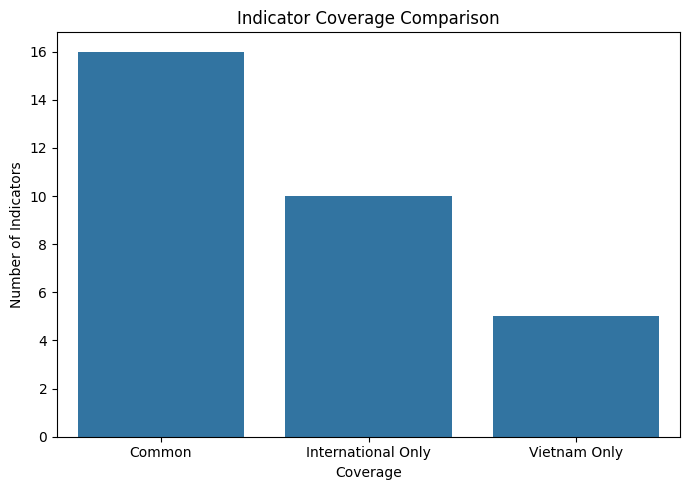

In [27]:
# Trực quan hóa số lượng indicator theo nhóm bao phủ

plt.figure(figsize=(7, 5))

sns.barplot(
    data=coverage_statistics,
    x="coverage",
    y="indicator_count"
)

plt.title("Indicator Coverage Comparison")
plt.xlabel("Coverage")
plt.ylabel("Number of Indicators")

plt.tight_layout()
plt.show()

# 4. DBI Indicator Mapping

Xây dựng bảng ánh xạ giữa Digital Burnout Indicator và DBI Framework nhằm xác định mỗi indicator thuộc chiều đo (DBI Dimension) và nhóm chỉ số (Indicator Group) tương ứng.

Do hai bộ dữ liệu chỉ lưu tên feature, bước này xây dựng bảng ánh xạ chuẩn của toàn bộ indicator theo DBI Framework. Bảng mapping sẽ được sử dụng xuyên suốt cho quá trình đánh giá tính nhất quán và xây dựng Final DBI Framework.

In [28]:
# Xây dựng bảng ánh xạ giữa indicator và DBI Framework

dbi_indicator_mapping = pd.DataFrame({

    "indicator": [

        # Psychological Symptoms

        "emotional_exhaustion",
        "stress_level",
        "mental_fatigue",
        "digital_exhaustion",
        "digital_stress",
        "loss_of_interest",

        # Digital Exposure

        "daily_screen_time",
        "social_media_hours",
        "doomscrolling_duration",
        "late_night_device_usage",
        "notification_count",
        "smartphone_unlocks",
        "app_switch_frequency",
        "meeting_hours",

        # Cognitive Performance

        "concentration_score",
        "distraction_frequency",
        "focus_sessions",
        "deep_work_hours",
        "task_completion_rate",
        "motivation_level",
        "performance_decline",
        "work_satisfaction",

        # Sleep and Recovery

        "sleep_hours",
        "sleep_quality",
        "physical_activity",
        "physical_fatigue",
        "caffeine_intake",

        # Context Variables

        "age",
        "workspace_quality",
        "internet_stability",
        "remote_work_days"

    ],

    "dbi_dimension": [

        "Psychological Symptoms",
        "Psychological Symptoms",
        "Psychological Symptoms",
        "Psychological Symptoms",
        "Psychological Symptoms",
        "Psychological Symptoms",

        "Digital Exposure",
        "Digital Exposure",
        "Digital Exposure",
        "Digital Exposure",
        "Digital Exposure",
        "Digital Exposure",
        "Digital Exposure",
        "Digital Exposure",

        "Cognitive Performance",
        "Cognitive Performance",
        "Cognitive Performance",
        "Cognitive Performance",
        "Cognitive Performance",
        "Cognitive Performance",
        "Cognitive Performance",
        "Cognitive Performance",

        "Sleep & Recovery",
        "Sleep & Recovery",
        "Sleep & Recovery",
        "Sleep & Recovery",
        "Sleep & Recovery",

        "Context Variables",
        "Context Variables",
        "Context Variables",
        "Context Variables"

    ]

})

print("Đã xây dựng DBI Indicator Mapping.")

display(dbi_indicator_mapping.head())

Đã xây dựng DBI Indicator Mapping.


,indicator,dbi_dimension
0,emotional_exhaustion,Psychological Symptoms
1,stress_level,Psychological Symptoms
2,mental_fatigue,Psychological Symptoms
3,digital_exhaustion,Psychological Symptoms
4,digital_stress,Psychological Symptoms


In [29]:
# Ghép thông tin Coverage với DBI Mapping

dbi_indicator_repository = (
    dbi_indicator_mapping
    .merge(
        indicator_coverage,
        on="indicator",
        how="left"
    )
)

print("Đã xây dựng bảng DBI Indicator Repository.")

display(
    dbi_indicator_repository.head()
)

Đã xây dựng bảng DBI Indicator Repository.


,indicator,dbi_dimension,coverage
0,emotional_exhaustion,Psychological Symptoms,Common
1,stress_level,Psychological Symptoms,International Only
2,mental_fatigue,Psychological Symptoms,International Only
3,digital_exhaustion,Psychological Symptoms,Vietnam Only
4,digital_stress,Psychological Symptoms,Vietnam Only


# 5. Indicator Consistency Analysis

Đánh giá mức độ nhất quán của từng Digital Burnout Indicator dựa trên bằng chứng thu được từ hai bộ dữ liệu.

Quá trình đánh giá được thực hiện dựa trên ba nguồn bằng chứng:

- Mức độ bao phủ giữa hai bộ dữ liệu.
- Kết quả Feature Validation.
- Kết quả SHAP Feature Importance.

Ba nguồn thông tin này sẽ được chuẩn hóa trước khi tổng hợp thành Consistency Score và Indicator Priority.

## 5.1 Feature Validation Evidence

Xác định indicator nào được lựa chọn sau Feature Validation của từng bộ dữ liệu.

Indicator sẽ được đánh dấu là có bằng chứng Feature Validation nếu xuất hiện trong kết quả Feature Validation của từng bộ dữ liệu.

In [30]:
# Chuẩn bị bằng chứng Feature Validation

international_validation_set = set(
    international_validation_std["indicator"]
)

vietnam_validation_set = set(
    vietnam_validation_std["indicator"]
)

In [31]:
# Xây dựng bảng Feature Validation Evidence

validation_evidence = dbi_indicator_repository.copy()

validation_evidence["international_validation"] = (
    validation_evidence["indicator"]
    .isin(international_validation_set)
)

validation_evidence["vietnam_validation"] = (
    validation_evidence["indicator"]
    .isin(vietnam_validation_set)
)

print("Đã xây dựng bằng chứng Feature Validation.")

display(
    validation_evidence[
        [
            "indicator",
            "international_validation",
            "vietnam_validation"
        ]
    ].head()
)

Đã xây dựng bằng chứng Feature Validation.


,indicator,international_validation,vietnam_validation
0,emotional_exhaustion,True,True
1,stress_level,True,False
2,mental_fatigue,True,False
3,digital_exhaustion,False,True
4,digital_stress,False,True


## 5.2 SHAP Evidence

Xác định indicator nào xuất hiện trong kết quả SHAP Feature Importance của từng bộ dữ liệu.

Indicator được đánh dấu là có bằng chứng SHAP nếu xuất hiện trong danh sách SHAP Feature Importance của mô hình tương ứng.

In [32]:
# Chuẩn bị bằng chứng SHAP

international_shap_set = set(
    international_shap_std["indicator"]
)

vietnam_shap_set = set(
    vietnam_shap_std["indicator"]
)

In [33]:
# Xây dựng bảng SHAP Evidence

shap_evidence = dbi_indicator_repository.copy()

shap_evidence["international_shap"] = (
    shap_evidence["indicator"]
    .isin(international_shap_set)
)

shap_evidence["vietnam_shap"] = (
    shap_evidence["indicator"]
    .isin(vietnam_shap_set)
)

print("Đã xây dựng bằng chứng SHAP Feature Importance.")

display(
    shap_evidence[
        [
            "indicator",
            "international_shap",
            "vietnam_shap"
        ]
    ].head()
)

Đã xây dựng bằng chứng SHAP Feature Importance.


,indicator,international_shap,vietnam_shap
0,emotional_exhaustion,True,False
1,stress_level,True,False
2,mental_fatigue,True,False
3,digital_exhaustion,False,False
4,digital_stress,False,False


## 5.3 Build Indicator Consistency Table

Tổng hợp toàn bộ bằng chứng đánh giá của từng Digital Burnout Indicator vào một bảng thống nhất nhằm phục vụ cho quá trình tính toán Consistency Score.

Ba nguồn thông tin được kết hợp bao gồm:

- DBI Indicator Mapping.
- Feature Validation Evidence.
- SHAP Feature Importance Evidence.

Kết quả tạo thành một bảng duy nhất, trong đó mỗi indicator được mô tả đầy đủ về:

- DBI Dimension.
- Coverage.
- Feature Validation.
- SHAP Feature Importance.

In [34]:
# Tổng hợp toàn bộ bằng chứng đánh giá của từng indicator

indicator_consistency_table = (
    dbi_indicator_repository
    .merge(
        validation_evidence[
            [
                "indicator",
                "international_validation",
                "vietnam_validation"
            ]
        ],
        on="indicator",
        how="left"
    )
    .merge(
        shap_evidence[
            [
                "indicator",
                "international_shap",
                "vietnam_shap"
            ]
        ],
        on="indicator",
        how="left"
    )
)

print("Đã xây dựng bảng Indicator Consistency.")

print(
    f"Số lượng indicator: {len(indicator_consistency_table)}"
)

display(
    indicator_consistency_table.head()
)

Đã xây dựng bảng Indicator Consistency.
Số lượng indicator: 31


,indicator,dbi_dimension,coverage,international_validation,vietnam_validation,international_shap,vietnam_shap
0,emotional_exhaustion,Psychological Symptoms,Common,True,True,True,False
1,stress_level,Psychological Symptoms,International Only,True,False,True,False
2,mental_fatigue,Psychological Symptoms,International Only,True,False,True,False
3,digital_exhaustion,Psychological Symptoms,Vietnam Only,False,True,False,False
4,digital_stress,Psychological Symptoms,Vietnam Only,False,True,False,False


## 5.4 Indicator Priority Classification

Phân loại mức độ ưu tiên của từng Digital Burnout Indicator dựa trên bằng chứng thu được từ hai bộ dữ liệu nghiên cứu.

Thay vì sử dụng điểm số tổng hợp, nghiên cứu áp dụng phương pháp phân loại theo luật (rule-based classification). Phương pháp này phù hợp với đặc điểm của Vietnam Dataset, trong đó một số indicator được loại khỏi mô hình học máy nhằm tránh hiện tượng rò rỉ dữ liệu (data leakage), mặc dù vẫn được xác nhận là những chỉ số quan trọng trong Feature Validation.

Indicator được chia thành ba nhóm:

- **Core Indicator**
- **Supporting Indicator**
- **Dataset-specific Indicator**

In [35]:
# Phân loại mức độ ưu tiên của từng indicator

def classify_indicator(row):

    # Indicator xuất hiện ở cả hai bộ dữ liệu
    if row["coverage"] == "Common":

        # Được xác nhận bởi Feature Validation của cả hai bộ dữ liệu
        if (
            row["international_validation"]
            and row["vietnam_validation"]
        ):
            return "Core Indicator"

        # Chỉ được xác nhận bởi một bộ dữ liệu
        return "Supporting Indicator"

    # Indicator chỉ xuất hiện ở một bộ dữ liệu
    return "Dataset-specific Indicator"


indicator_consistency_table["indicator_priority"] = (
    indicator_consistency_table.apply(
        classify_indicator,
        axis=1
    )
)

print("Đã phân loại mức độ ưu tiên của indicator.")


Đã phân loại mức độ ưu tiên của indicator.


In [36]:
# Hiển thị kết quả phân loại

display(
    indicator_consistency_table[
        [
            "indicator",
            "coverage",
            "international_validation",
            "vietnam_validation",
            "international_shap",
            "vietnam_shap",
            "indicator_priority"
        ]
    ]
)

,indicator,coverage,international_validation,vietnam_validation,international_shap,vietnam_shap,indicator_priority
0,emotional_exhaustion,Common,True,True,True,False,Core Indicator
1,stress_level,International Only,True,False,True,False,Dataset-specific Indicator
2,mental_fatigue,International Only,True,False,True,False,Dataset-specific Indicator
3,digital_exhaustion,Vietnam Only,False,True,False,False,Dataset-specific Indicator
4,digital_stress,Vietnam Only,False,True,False,False,Dataset-specific Indicator
5,loss_of_interest,Vietnam Only,False,True,False,False,Dataset-specific Indicator
6,daily_screen_time,Common,True,True,True,True,Core Indicator
7,social_media_hours,Common,True,True,True,True,Core Indicator
8,doomscrolling_duration,Common,True,True,True,True,Core Indicator
9,late_night_device_usage,Common,True,True,True,True,Core Indicator


## 5.5 Indicator Priority Summary

Thống kê số lượng indicator theo từng mức độ ưu tiên nhằm tổng hợp kết quả của quá trình đánh giá tính nhất quán.

Các indicator được tổng hợp theo ba nhóm:

- Core Indicator
- Supporting Indicator
- Dataset-specific Indicator

Kết quả này là cơ sở để xây dựng Final DBI Framework ở phần tiếp theo.

In [37]:
# Thống kê số lượng indicator theo từng mức độ ưu tiên

indicator_priority_summary = (
    indicator_consistency_table["indicator_priority"]
    .value_counts()
    .rename_axis("indicator_priority")
    .reset_index(name="indicator_count")
)

indicator_priority_summary["percentage"] = (
    indicator_priority_summary["indicator_count"]
    / len(indicator_consistency_table)
    * 100
).round(2)

print("Đã thống kê mức độ ưu tiên của indicator.")

display(indicator_priority_summary)

Đã thống kê mức độ ưu tiên của indicator.


,indicator_priority,indicator_count,percentage
0,Core Indicator,16,51.61
1,Dataset-specific Indicator,15,48.39


In [38]:
# Hiển thị danh sách indicator theo từng mức độ ưu tiên

for priority in [
    "Core Indicator",
    "Supporting Indicator",
    "Dataset-specific Indicator"
]:

    print(f"\n{priority}")

    display(
        indicator_consistency_table.loc[
            indicator_consistency_table["indicator_priority"] == priority,
            [
                "indicator",
                "dbi_dimension",
                "coverage"
            ]
        ].reset_index(drop=True)
    )


Core Indicator


,indicator,dbi_dimension,coverage
0,emotional_exhaustion,Psychological Symptoms,Common
1,daily_screen_time,Digital Exposure,Common
2,social_media_hours,Digital Exposure,Common
3,doomscrolling_duration,Digital Exposure,Common
4,late_night_device_usage,Digital Exposure,Common
5,notification_count,Digital Exposure,Common
6,smartphone_unlocks,Digital Exposure,Common
7,app_switch_frequency,Digital Exposure,Common
8,concentration_score,Cognitive Performance,Common
9,distraction_frequency,Cognitive Performance,Common



Supporting Indicator


,indicator,dbi_dimension,coverage



Dataset-specific Indicator


,indicator,dbi_dimension,coverage
0,stress_level,Psychological Symptoms,International Only
1,mental_fatigue,Psychological Symptoms,International Only
2,digital_exhaustion,Psychological Symptoms,Vietnam Only
3,digital_stress,Psychological Symptoms,Vietnam Only
4,loss_of_interest,Psychological Symptoms,Vietnam Only
5,meeting_hours,Digital Exposure,International Only
6,performance_decline,Cognitive Performance,Vietnam Only
7,work_satisfaction,Cognitive Performance,International Only
8,physical_activity,Sleep & Recovery,International Only
9,physical_fatigue,Sleep & Recovery,Vietnam Only


# 6. Final DBI Framework Construction

Xây dựng bộ khung Digital Burnout Indicator (DBI) cuối cùng dựa trên kết quả phân loại mức độ ưu tiên của indicator.

Phần này tổng hợp toàn bộ bằng chứng đã phân tích trong các phần trước:

- DBI Dimension.
- Indicator Coverage.
- Feature Validation Evidence.
- SHAP Feature Importance Evidence.
- Indicator Priority Classification.

Kết quả tạo ra hai bộ dữ liệu:

- Final DBI Framework: toàn bộ indicator được xác định trong nghiên cứu.
- Core DBI Indicators: nhóm indicator cốt lõi được xác nhận trên cả hai bộ dữ liệu.

## 6.1 Construct Final DBI Framework

Tạo bảng DBI Framework cuối cùng chứa toàn bộ indicator và bằng chứng đánh giá.

Bảng framework cuối cùng bao gồm toàn bộ 31 indicator cùng các thông tin:

- Dimension thuộc DBI Framework.
- Mức độ xuất hiện giữa hai dataset.
- Bằng chứng Feature Validation.
- Bằng chứng SHAP.
- Mức độ ưu tiên.

In [39]:
# Tạo Final DBI Framework

final_dbi_framework = (
    indicator_consistency_table
    .copy()
)

print("Đã xây dựng Final DBI Framework.")

print(
    f"Số lượng indicator trong framework: {len(final_dbi_framework)}"
)

display(
    final_dbi_framework.head()
)

Đã xây dựng Final DBI Framework.
Số lượng indicator trong framework: 31


,indicator,dbi_dimension,coverage,international_validation,vietnam_validation,international_shap,vietnam_shap,indicator_priority
0,emotional_exhaustion,Psychological Symptoms,Common,True,True,True,False,Core Indicator
1,stress_level,Psychological Symptoms,International Only,True,False,True,False,Dataset-specific Indicator
2,mental_fatigue,Psychological Symptoms,International Only,True,False,True,False,Dataset-specific Indicator
3,digital_exhaustion,Psychological Symptoms,Vietnam Only,False,True,False,False,Dataset-specific Indicator
4,digital_stress,Psychological Symptoms,Vietnam Only,False,True,False,False,Dataset-specific Indicator


## 6.2 Export Final DBI Framework

Lưu lại bộ DBI Framework cuối cùng để sử dụng cho các phân tích tiếp theo.

Bảng kết quả được lưu vào thư mục `data/final/` nhằm phục vụ việc tái sử dụng trong các notebook sau.

In [40]:
# Lưu Final DBI Framework

final_framework_path = (
    project_path
    / "data"
    / "final"
    / "final_dbi_framework.csv"
)

final_dbi_framework.to_csv(
    final_framework_path,
    index=False,
    encoding="utf-8"
)

print("Đã lưu Final DBI Framework.")

Đã lưu Final DBI Framework.


## 6.3 Export Core DBI Indicators

Trích xuất nhóm indicator cốt lõi đại diện cho DBI Framework.

Core Indicator là các indicator:

- Xuất hiện trong cả hai bộ dữ liệu.
- Được xác nhận thông qua Feature Validation.

Nhóm này được sử dụng làm nền tảng chính trong việc xây dựng và diễn giải DBI.

In [41]:
# Lọc Core DBI Indicators

core_dbi_indicators = (
    final_dbi_framework[
        final_dbi_framework["indicator_priority"]
        == "Core Indicator"
    ]
    .reset_index(drop=True)
)

print(
    f"Số lượng Core Indicator: {len(core_dbi_indicators)}"
)

display(core_dbi_indicators)

Số lượng Core Indicator: 16


,indicator,dbi_dimension,coverage,international_validation,vietnam_validation,international_shap,vietnam_shap,indicator_priority
0,emotional_exhaustion,Psychological Symptoms,Common,True,True,True,False,Core Indicator
1,daily_screen_time,Digital Exposure,Common,True,True,True,True,Core Indicator
2,social_media_hours,Digital Exposure,Common,True,True,True,True,Core Indicator
3,doomscrolling_duration,Digital Exposure,Common,True,True,True,True,Core Indicator
4,late_night_device_usage,Digital Exposure,Common,True,True,True,True,Core Indicator
5,notification_count,Digital Exposure,Common,True,True,True,True,Core Indicator
6,smartphone_unlocks,Digital Exposure,Common,True,True,True,True,Core Indicator
7,app_switch_frequency,Digital Exposure,Common,True,True,True,True,Core Indicator
8,concentration_score,Cognitive Performance,Common,True,True,True,True,Core Indicator
9,distraction_frequency,Cognitive Performance,Common,True,True,True,True,Core Indicator


In [42]:
# Lưu Core DBI Indicators

core_indicator_path = (
    project_path
    / "data"
    / "final"
    / "core_dbi_indicators.csv"
)

core_dbi_indicators.to_csv(
    core_indicator_path,
    index=False,
    encoding="utf-8"
)

print("Đã lưu Core DBI Indicators.")

Đã lưu Core DBI Indicators.
